In [54]:
#!/bin/bash
# ! kaggle datasets download kuantinglai/taiwanese-food-101

In [55]:
# ! unzip taiwanese-food-101.zip -d taiwanese-food-101

In [56]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from torch.utils.tensorboard import SummaryWriter
from PIL import Image
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns


# 設置設備
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [110]:
import pandas as pd

df = pd.read_csv("taiwanese-food-101/tw_food_101_classes.csv", header=None)

total_classes = df[1].tolist()

print(total_classes)  # 確保讀取正確


['bawan', 'beef_noodles', 'beef_soup', 'bitter_melon_with_salted_eggs', 'braised_napa_cabbage', 'braised_pork_over_rice', 'brown_sugar_cake', 'bubble_tea', 'caozaiguo', 'chicken_mushroom_soup', 'chinese_pickled_cucumber', 'coffin_toast', 'cold_noodles', 'crab_migao', 'deep-fried_chicken_cutlets', 'deep_fried_pork_rib_and_radish_soup', 'dried_shredded_squid', 'egg_pancake_roll', 'eight_treasure_shaved_ice', 'fish_head_casserole', 'fried-spanish_mackerel_thick_soup', 'fried_eel_noodles', 'fried_instant_noodles', 'fried_rice_noodles', 'ginger_duck_stew', 'grilled_corn', 'grilled_taiwanese_sausage', 'hakka_stir-fried', 'hot_sour_soup', 'hung_rui_chen_sandwich', 'intestine_and_oyster_vermicelli', 'iron_egg', 'jelly_of_gravey_and_chicken_feet_skin', 'jerky', 'kung-pao_chicken', 'luwei', 'mango_shaved_ice', 'meat_dumpling_in_chili_oil', 'milkfish_belly_congee', 'mochi', 'mung_bean_smoothie_milk', 'mutton_fried_noodles', 'mutton_hot_pot', 'nabeyaki_egg_noodles', 'night_market_steak', 'nougat',

In [136]:
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, selected_classes, transform=None, split=None, validation_split=0.2, subset=None, seed=42):
        self.root_dir = root_dir
        self.selected_classes = selected_classes
        self.transform = transform
        self.split = split
        self.subset = subset
        self.validation_split = validation_split
        self.seed = seed
        
        # 讀取所有資料夾中的圖片路徑和標籤
        self.image_paths = []
        self.labels = []
        
        # 如果是測試集，標籤為 None
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(self.selected_classes)}

        if self.subset == 'testing':
            # 在測試集模式下，所有圖片都放在一個資料夾中
            for filename in os.listdir(self.root_dir):
                img_path = os.path.join(self.root_dir, filename)
                if True:
                    self.image_paths.append(img_path)
                    self.labels.append(None)  # 測試集沒有標籤，所以設為 None
        else:
            # 如果是訓練或驗證集，按照類別處理
            for class_name in self.selected_classes:
                class_folder = os.path.join(self.root_dir, class_name)
                if os.path.isdir(class_folder):
                    for filename in os.listdir(class_folder):
                        img_path = os.path.join(class_folder, filename)
                        if True:
                            self.image_paths.append(img_path)
                            self.labels.append(self.class_to_idx[class_name])

            # 切割訓練和驗證集
            if self.split:
                train_paths, val_paths, train_labels, val_labels = train_test_split(
                    self.image_paths, self.labels, test_size=self.validation_split, random_state=self.seed, stratify=self.labels)
                if self.subset == 'validation':
                    self.image_paths, self.labels = val_paths, val_labels
                else:
                    self.image_paths, self.labels = train_paths, train_labels

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            image = Image.open(img_path)
         
            # 確保圖片是 RGB 模式
            if image.mode != "RGB":
                # print(f"Converting {img_path} from {image.mode} to RGB")  # Debug
                image = image.convert("RGB")

        except Exception as e:
            return self.__getitem__((idx + 1) % len(self.image_paths))  # 如果讀取出錯，重試
        
        label = self.labels[idx]
        
        # 應用轉換（例如縮放、裁剪等）
        if self.transform:
            image = self.transform(image)
        
        return image, label


In [ ]:
# 設定轉換（對於圖像大小、標準化等處理）
train_transform = transforms.Compose([
    transforms.AutoAugment(),
    # transforms.Resize((224, 224)), # Vit
    transforms.Resize((256, 256)), # ResNet
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    # transforms.Resize((224, 224)), # Vit
    transforms.Resize((256, 256)), # ResNet
    transforms.ToTensor(),  # 轉換為 Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
])

# 創建訓練資料集
train_ds = CustomImageDataset(
    root_dir='taiwanese-food-101/tw_food_101/tw_food_101/train', 
    selected_classes= total_classes,
    transform=train_transform,
    split=True,  # 分割訓練和驗證集
    subset='training'  # 訓練集
)

# 創建驗證資料集
val_ds = CustomImageDataset(
    root_dir='taiwanese-food-101/tw_food_101/tw_food_101/train', 
    selected_classes= total_classes,
    transform=val_transform,
    split=True,  # 分割訓練和驗證集
    subset='validation'  # 驗證集
)

# 創建測試資料集
test_ds = CustomImageDataset(
    root_dir='taiwanese-food-101/tw_food_101/tw_food_101/test', 
    selected_classes= total_classes,
    transform=val_transform,
    subset='testing'
)

# 使用 DataLoader
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4, pin_memory= True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4, pin_memory= True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=4, pin_memory= True)


Batch images shape: torch.Size([16, 3, 256, 256])
Batch labels shape: torch.Size([16])
First label in batch: 39


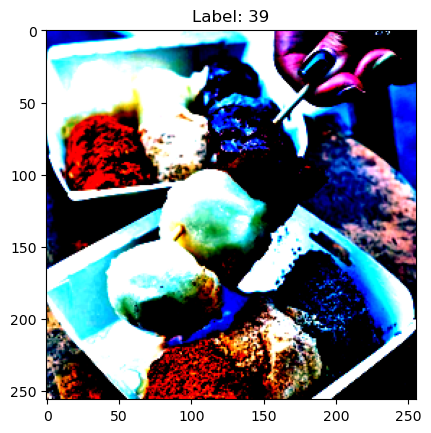

In [155]:
import matplotlib.pyplot as plt
import numpy as np

# 顯示第一個批次中的第一張圖片
for images, labels in train_loader:
    print(f"Batch images shape: {images.shape}")
    print(f"Batch labels shape: {labels.shape}")
    print(f"First label in batch: {labels[0]}")  # 查看第一個圖片的標籤
    
    # 顯示第一張圖片
    first_image = images[0].permute(1, 2, 0).numpy()  # 將 Tensor 轉換為 NumPy 陣列並調整通道順序 (C, H, W) -> (H, W, C)
    first_image = np.clip(first_image, 0, 1)  # 確保數值在 0 到 1 之間
    plt.imshow(first_image)
    plt.title(f"Label: {labels[0]}")
    plt.show()
    break  # 只顯示第一個批次，防止繼續遍歷


In [ ]:
# # 定義 Vision Transformer 模型
# model = models.vit_b_32(weights=models.ViT_B_32_Weights.IMAGENET1K_V1)

# for param in model.parameters():
#     param.requires_grad = False

# model.heads[0] = nn.Sequential(
#     nn.Dropout(p=0.5),  # 加入 Dropout 層
#     nn.Linear(model.heads[0].in_features, len(total_classes))
# )

# for param in model.heads.parameters():
#     param.requires_grad = True

# model.to(device)

# # 定義損失函數和優化器
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
# # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
# #     optimizer,  # 你使用的優化器
# #     mode='min',  # 目標指標的最小化（例如：損失函數）
# #     patience=5,  # 訓練若在 3 個 epoch 內未改善，則調整學習率
# #     factor=0.5,  # 每次調整學習率的縮小因子（例如：將學習率減少一半）
# #     min_lr=1e-7  # 最小學習率，防止學習率過低
# # )
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)
#=============================================================================================================================
# 定義 ResNet 模型
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)  # 使用 ResNet50 預訓練模型

# 修改最後的全連接層（分類層）
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),  # 加入 Dropout 層
    nn.Linear(model.fc.in_features, len(total_classes))  # 修改輸出層的大小
)

# 轉移模型到設備（如 GPU）
model.to(device)

# 定義損失函數和優化器
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 只對未凍結的層進行優化
optimizer = optim.AdamW(model.fc.parameters(), lr=5e-5, weight_decay=1e-4)

# 使用 Cosine Annealing 學習率調度器
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.2, patience=5)



In [158]:
from tqdm import tqdm  # ✅ 引入 tqdm 來顯示進度條

# 自定義 Logger
class EpochLogger:
    def __init__(self):
        self.history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

    def log_epoch(self, epoch, train_loss, train_accuracy, val_loss, val_accuracy, epoch_time):
        self.history["loss"].append(train_loss)
        self.history["accuracy"].append(train_accuracy)
        self.history["val_loss"].append(val_loss)
        self.history["val_accuracy"].append(val_accuracy)

        print(f"\nEpoch {epoch + 1}:")
        print(f"  - Train Loss: {train_loss:.4f}")
        print(f"  - Train Accuracy: {train_accuracy:.4f}")
        print(f"  - Val Loss: {val_loss:.4f}")
        print(f"  - Val Accuracy: {val_accuracy:.4f}")
        print(f"  - Epoch Time: {epoch_time:.2f} seconds", flush=True)  # ✅ 確保即時輸出

# 訓練模型
num_epochs = 50
best_val_accuracy = 0.0
epoch_logger = EpochLogger()

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    start_time = time.time()

    # ✅ 使用 tqdm 來顯示 batch 訓練進度
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

    for inputs, labels in train_loader_tqdm:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        # print("outputs shape:", outputs.shape)
        # print("labels shape:", labels.shape)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        # ✅ 更新 tqdm 進度條顯示 loss
        train_loader_tqdm.set_postfix(loss=loss.item(), accuracy=correct_train / total_train)

    train_loss /= total_train
    train_accuracy = correct_train / total_train

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        val_loader_tqdm = tqdm(val_loader, desc=f"Validation {epoch+1}/{num_epochs}", leave=False)  # ✅ Validation 也加進度條

        for inputs, labels in val_loader_tqdm:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            # ✅ 更新 tqdm 進度條顯示 loss
            val_loader_tqdm.set_postfix(loss=loss.item(), accuracy=correct_val / total_val)

    val_loss /= total_val
    val_accuracy = correct_val / total_val

    epoch_time = time.time() - start_time
    epoch_logger.log_epoch(epoch, train_loss, train_accuracy, val_loss, val_accuracy, epoch_time)

    # 獲取當前學習率
    current_lr = scheduler.get_last_lr()[0]  
    print(f"Current LR: {current_lr:.6f}")

    scheduler.step(val_loss)

    # ✅ 保存最佳模型
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), "hw2_weight/best_food_vit.pth")

print("\n🎉 Training Complete.")


Epoch 1/50:  19%|█▊        | 191/1019 [00:24<01:15, 11.04it/s, accuracy=0.00999, loss=4.56]/home/rvl1421/miniconda3/envs/mingwei_dp_env/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
Epoch 1/50:  27%|██▋       | 273/1019 [00:33<01:02, 11.92it/s, accuracy=0.0105, loss=4.59] /home/rvl1421/miniconda3/envs/mingwei_dp_env/lib/python3.10/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 1/50:  31%|███       | 314/1019 [00:36<00:58, 11.95it/s, accuracy=0.0112, loss=4.51]/home/rvl1421/miniconda3/envs/mingwei_dp_env/lib/python3.10/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 1/50:  42%|████▏     | 428/1019 [00:45<00:44, 13.28it/s, accuracy=0.0124, loss=4.55]/home/rvl1421/miniconda3/envs/mingwei_dp_env/lib/python3.


Epoch 1:
  - Train Loss: 4.5918
  - Train Accuracy: 0.0191
  - Val Loss: 4.5410
  - Val Accuracy: 0.0439
  - Epoch Time: 108.26 seconds


Current LR: 0.000010


Epoch 2/50:  14%|█▍        | 142/1019 [00:11<01:10, 12.38it/s, accuracy=0.0302, loss=4.6] /home/rvl1421/miniconda3/envs/mingwei_dp_env/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
Epoch 2/50:  24%|██▍       | 247/1019 [00:19<01:04, 11.89it/s, accuracy=0.0323, loss=4.54]/home/rvl1421/miniconda3/envs/mingwei_dp_env/lib/python3.10/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 2/50:  55%|█████▍    | 560/1019 [00:45<00:37, 12.27it/s, accuracy=0.0384, loss=4.55]/home/rvl1421/miniconda3/envs/mingwei_dp_env/lib/python3.10/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 2/50:  71%|███████   | 724/1019 [00:57<00:23, 12.74it/s, accuracy=0.0404, loss=4.45]/home/rvl1421/miniconda3/envs/mingwei_dp_env/lib/python3.10


Epoch 2:
  - Train Loss: 4.5177
  - Train Accuracy: 0.0415
  - Val Loss: 4.4712
  - Val Accuracy: 0.0739
  - Epoch Time: 97.50 seconds


...

Epoch 13/50:  24%|██▎       | 242/1019 [00:19<00:55, 13.98it/s, accuracy=0.271, loss=3.87]/home/rvl1421/miniconda3/envs/mingwei_dp_env/lib/python3.10/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 13/50:  37%|███▋      | 379/1019 [00:29<00:47, 13.41it/s, accuracy=0.269, loss=3.91]/home/rvl1421/miniconda3/envs/mingwei_dp_env/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
Epoch 13/50:  43%|████▎     | 436/1019 [00:34<00:57, 10.22it/s, accuracy=0.269, loss=3.89]/home/rvl1421/miniconda3/envs/mingwei_dp_env/lib/python3.10/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 13/50:  66%|██████▌   | 675/1019 [00:54<00:25, 13.33it/s, accuracy=0.268, loss=3.95]/home/rvl1421/miniconda3/envs/mingwei_dp_env/lib/python3.10


Epoch 13:
  - Train Loss: 3.9279
  - Train Accuracy: 0.2710
  - Val Loss: 3.8392
  - Val Accuracy: 0.3973
  - Epoch Time: 97.21 seconds


Current LR: 0.000010


Epoch 14/50:  13%|█▎        | 130/1019 [00:10<01:14, 11.97it/s, accuracy=0.275, loss=3.91]/home/rvl1421/miniconda3/envs/mingwei_dp_env/lib/python3.10/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 14/50:  25%|██▍       | 252/1019 [00:20<00:57, 13.35it/s, accuracy=0.28, loss=3.81] /home/rvl1421/miniconda3/envs/mingwei_dp_env/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
Epoch 14/50:  55%|█████▍    | 556/1019 [00:43<00:38, 11.90it/s, accuracy=0.279, loss=4.06]/home/rvl1421/miniconda3/envs/mingwei_dp_env/lib/python3.10/site-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 14/50:  63%|██████▎   | 647/1019 [00:50<00:29, 12.71it/s, accuracy=0.281, loss=4]   


KeyboardInterrupt: 

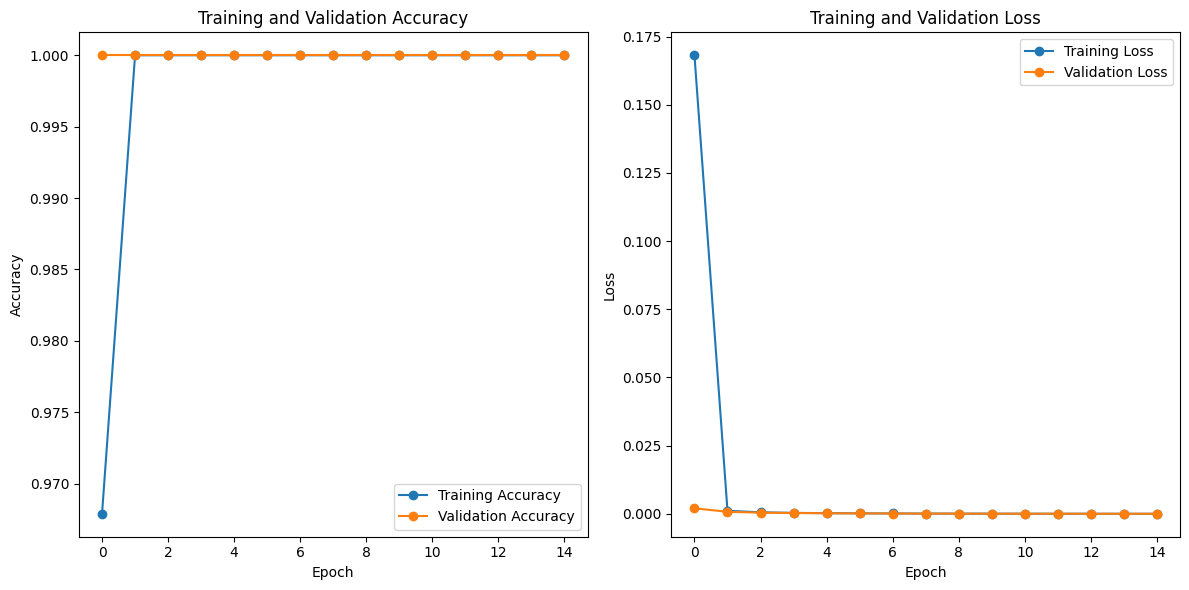

In [ ]:
# 繪製圖表
history = epoch_logger.history

plt.figure(figsize=(12, 6))

# 繪製準確率
plt.subplot(1, 2, 1)
plt.plot(history["accuracy"], label="Training Accuracy", marker="o")
plt.plot(history["val_accuracy"], label="Validation Accuracy", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

# 繪製損失
plt.subplot(1, 2, 2)
plt.plot(history["loss"], label="Training Loss", marker="o")
plt.plot(history["val_loss"], label="Validation Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

F1 Score: 1.0000


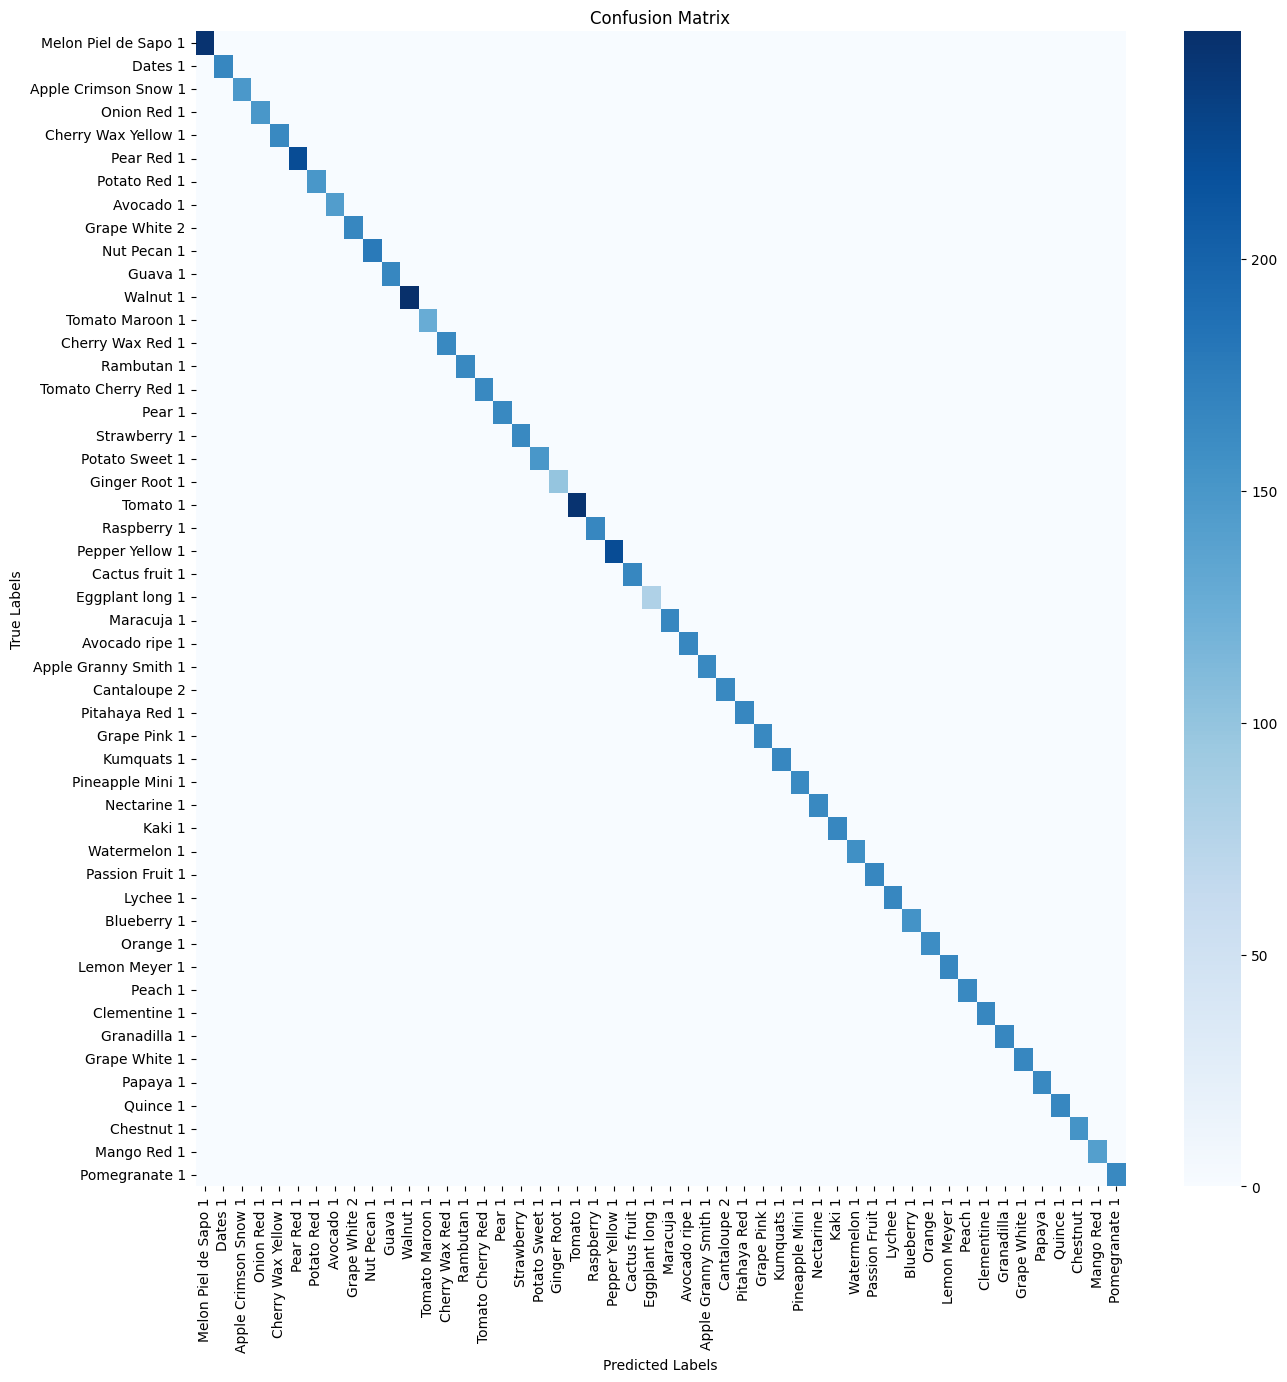

In [ ]:
# 測試模型並收集真實標籤和預測標籤
model.eval()
y_true = []
y_pred_classes = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())  # 真實標籤
        y_pred_classes.extend(preds.cpu().numpy())  # 預測標籤

# 計算混淆矩陣
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# 計算 F1 Score
f1 = f1_score(y_true, y_pred_classes, average='weighted')  # weighted 平均 F1 Score
print(f"F1 Score: {f1:.4f}")

# 顯示混淆矩陣
plt.figure(figsize=(15, 15))
sns.heatmap(conf_matrix, annot=False, fmt='d', cmap='Blues', xticklabels=selected_classes, yticklabels=selected_classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()